In [87]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [88]:
data = pd.read_csv("data.csv")
data = data.dropna(axis=1, how='all')

x = data.drop(columns=['id', 'diagnosis']).values
y = data['diagnosis'].values

scaler = StandardScaler()
x = scaler.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

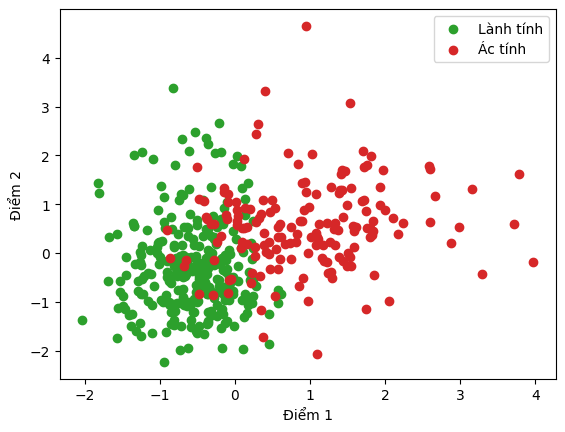

In [89]:
plt.scatter(X_train[y_train == 'B', 0], X_train[y_train == 'B', 1], color='tab:green', label='Lành tính')
plt.scatter(X_train[y_train == 'M', 0], X_train[y_train == 'M', 1], color='tab:red', label='Ác tính')
plt.xlabel('Điểm 1')
plt.ylabel('Điểm 2')
plt.legend()
plt.show()

In [90]:
def euclidean_distance(a, b):
  return np.sqrt(np.sum((b - a) ** 2))

In [91]:
class KNN:
  def __init__(self, k):
    self.k = k

  def fit(self, X, y):
    self.X_train = X
    self.y_train = y

  def predict(self, new_points):
    predictions = [self.predict_class(new_point) for new_point in new_points]
    return np.array(predictions)

  def predict_class(self, new_point):
    distances = [euclidean_distance(point, new_point) for point in self.X_train]

    k_nearest_indices = np.argsort(distances)[:self.k]
    k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

    most_common = Counter(k_nearest_labels).most_common(1)[0][0]
    return most_common

In [101]:
knn = KNN(3)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
accuracy = np.mean(predictions == y_test) * 100
print(f'Accuracy:{accuracy:.2f}%')

Accuracy:98.25%


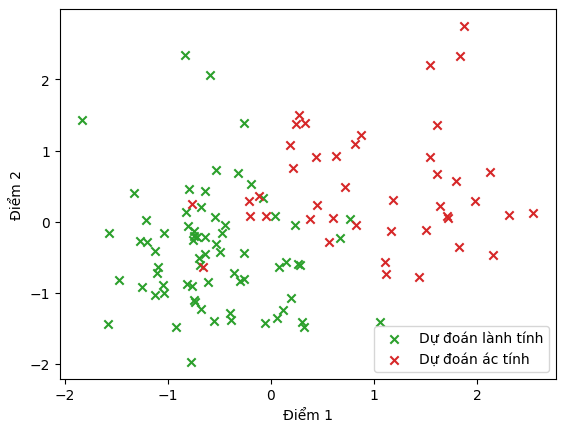

In [102]:
plt.scatter(X_test[predictions == 'B', 0], X_test[predictions == 'B', 1], color='tab:green', label='Dự đoán lành tính', marker='x')
plt.scatter(X_test[predictions == 'M', 0], X_test[predictions == 'M', 1], color='tab:red', label='Dự đoán ác tính', marker='x')
plt.xlabel('Điểm 1')
plt.ylabel('Điểm 2')
plt.legend()
plt.show()